# Predicting Plant Species Thriving Likelihood

#### Import dependencies

In [1]:
#!pip install pandas scikit-learn matplotlib seaborn gradio
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

#### Load the dataset using pandas	

In [2]:
data = pd.read_csv(r"plants_dataset_euhm_itai_07.csv")

#### Print the first few rows to inspect the data	

In [3]:
data.head()

,Soil Type,Sunlight (hours/day),Water Supply (liters/week),Temperature (C),pH Level,Plant Species,Thrives
0,Sandy,1.54,8.94,11.35,8.23,Fern,0
1,Sandy,2.67,36.45,NaN,8.40,Rose,0
2,Sandy,9.27,8.15,24.98,7.23,Cactus,1
3,Loamy,5.45,26.95,9.05,8.42,NaN,0
4,Loamy,8.19,21.08,21.62,6.96,Rose,1


#### Check for any missing values

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Soil Type                   195 non-null    object 
 1   Sunlight (hours/day)        188 non-null    float64
 2   Water Supply (liters/week)  195 non-null    float64
 3   Temperature (C)             189 non-null    float64
 4   pH Level                    187 non-null    float64
 5   Plant Species               189 non-null    object 
 6   Thrives                     200 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 11.1+ KB


In [5]:
data.isna().sum()

Soil Type                      5
Sunlight (hours/day)          12
Water Supply (liters/week)     5
Temperature (C)               11
pH Level                      13
Plant Species                 11
Thrives                        0
dtype: int64

#### Handle any missing values

In [6]:
data.dropna(inplace=True)

In [7]:
data.isna().sum()

Soil Type                     0
Sunlight (hours/day)          0
Water Supply (liters/week)    0
Temperature (C)               0
pH Level                      0
Plant Species                 0
Thrives                       0
dtype: int64

#### Encode categorical columns

In [9]:
categorical_cols = ["Soil Type", "Plant Species"]
le = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

#### Normalize or scale numeric columns

In [10]:
numerical_cols = ['Sunlight (hours/day)', 'Water Supply (liters/week)', 'Temperature (C)', 'pH Level']

scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

#### Generate summary statistics of the dataset	

In [11]:
data.describe()

,Soil Type,Sunlight (hours/day),Water Supply (liters/week),Temperature (C),pH Level,Plant Species,Thrives
count,147.000000,1.470000e+02,1.470000e+02,1.470000e+02,1.470000e+02,147.000000,147.000000
mean,1.115646,1.654006e-16,-1.208406e-16,-1.888134e-16,-5.135726e-17,1.000000,0.496599
std,0.831874,1.003419e+00,1.003419e+00,1.003419e+00,1.003419e+00,0.819288,0.501698
min,0.000000,-1.499746e+00,-1.381659e+00,-1.707738e+00,-1.794332e+00,0.000000,0.000000
25%,0.000000,-8.182730e-01,-8.875115e-01,-6.579910e-01,-7.092658e-01,0.000000,0.000000
50%,1.000000,-2.039125e-02,-4.796494e-02,-9.587497e-02,3.272783e-02,1.000000,0.000000
75%,2.000000,7.556639e-01,6.957775e-01,8.222811e-01,9.422684e-01,2.000000,1.000000
max,2.000000,1.652978e+00,1.895850e+00,1.762286e+00,1.373103e+00,2.000000,1.000000


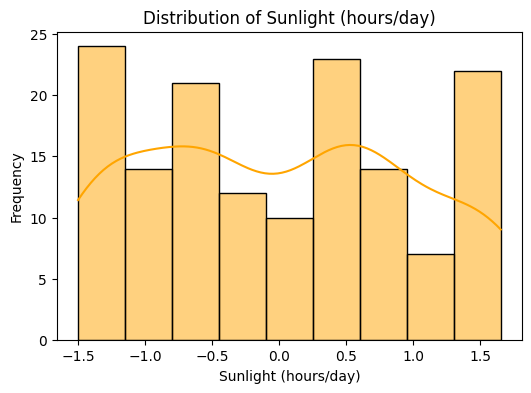

In [12]:
plt.figure(figsize=(6, 4))
sns.histplot(data['Sunlight (hours/day)'], kde=True, color='orange')
plt.title('Distribution of Sunlight (hours/day)')
plt.xlabel('Sunlight (hours/day)')
plt.ylabel('Frequency')
plt.show()

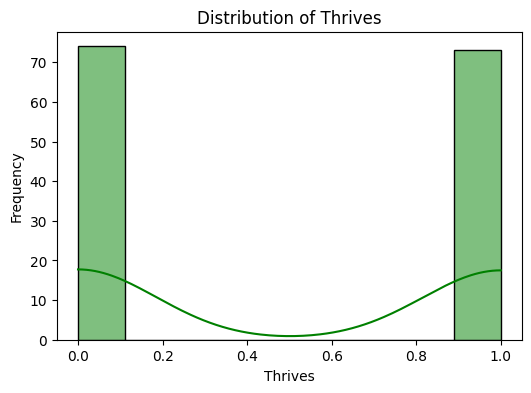

In [16]:
plt.figure(figsize=(6, 4))
sns.histplot(data['Thrives'], kde=True, color='green')
plt.title('Distribution of Thrives')
plt.xlabel('Thrives')
plt.ylabel('Frequency')
plt.show()

#### Separate features (X) and labels (y).

In [17]:
x = data.drop("Thrives", axis=1)
y = data["Thrives"]

#### Use train_test_split from sklearn to split the data into 80% training and 20% testing	

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Logistic Regression

In [19]:
lr = LogisticRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)

print("Logistic Regression Metrics:")
print("Accuracy =", accuracy_score(y_test, lr_y_pred))
print("Precision =", precision_score(y_test, lr_y_pred))
print("Recall =", recall_score(y_test, lr_y_pred))
print("F1-Score =", f1_score(y_test, lr_y_pred))

Logistic Regression Metrics:
Accuracy = 0.5
Precision = 0.5
Recall = 0.4
F1-Score = 0.4444444444444444


#### Decision Tree Classifier

In [20]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_y_pred = dt.predict(x_test)

print("Decision Tree Classifier Metrics:")
print("Accuracy =", accuracy_score(y_test, dt_y_pred))
print("Precision =", precision_score(y_test, dt_y_pred))
print("Recall =", recall_score(y_test, dt_y_pred))
print("F1-Score =", f1_score(y_test, dt_y_pred))

Decision Tree Classifier Metrics:
Accuracy = 1.0
Precision = 1.0
Recall = 1.0
F1-Score = 1.0


#### Generate the confusion matrix.	

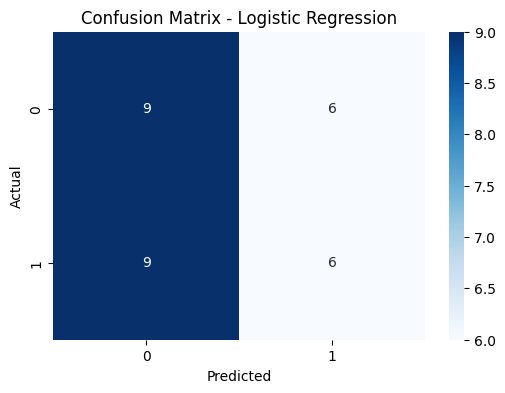

In [21]:
cm = confusion_matrix(y_test, lr_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Use GridSearchCV or RandomizedSearchCV to find optimal parameters for models.	

In [22]:
param_grid = {
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(x_train, y_train)
best_dt = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Best Score: 0.9655797101449275


In [23]:
def predict(st, sl, ws, temp, ph, ps):
    try:
        input_data = pd.DataFrame({
            "Soil Type": [st],
            "Sunlight (hours/day)": [sl],
            "Water Supply (liters/week)": [ws],
            "Temperature (C)": [temp],
            "pH Level": [ph],
            "Plant Species": [ps],
        })
        
        for col in categorical_cols:
            input_data[col] = le[col].transform(input_data[col])
        
        input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])
        
        prediction = dt.predict(input_data)[0]
        
        if prediction == 1:
            return "Yes, The plant will Thrive "
        else:
            return "No, The plant will NOT Thrive in these conditions"
            
    except Exception as e:
        return f" Error: {e}"

In [ ]:
gr.Interface(
    fn = predict,
    inputs = [
        gr.Dropdown(label = "Soil Type" , choices = ["Sandy" , "Loamy" , "Clay"]),
        gr.Number(label = "Sunlight (hours/day)"),
        gr.Number(label = "Water Supply (liters/week)"),
        gr.Number(label = "Temperature (C)"),
        gr.Number(label = "pH Level"),
        gr.Dropdown(label = "Plant Species" , choices = ["Fern" , "Rose" , "Cactus"]),
    ],
    outputs = "text",
    title = "plants thrives",
).launch()

* Running on local URL:  http://127.0.0.1:7869
* To create a public link, set `share=True` in `launch()`.
